# Python Take-Home Salary & Tax Calculator Project

I wanted to make a calculator to see how much take-home salary you get depending on your income. This both helps me to see the income split and I can use the calculator in the future. First, I note the income tax and National Insurance rates depending on salary (earnings are per year):

### Income tax:

* 0% tax on earnings up to £12,570
* 20% tax on earnings from £12,570 to £50,270
* 40% tax on earnings from £50,270 to £125,140
* 45% tax on earnings above £125,140

There is also a personal allowance (£12,570 tax-free) reduction as follows:

* You lose £1 of your Personal Allowance for every £2 you make above £100,000.

### National Insurance:

* 0% NI on earnings up to £12,570
* 8% NI on earnings from £12,570 to £50,270
* 2% NI on earnings above £50,270

There are also Student Loans, which operate somewhat like a graduate tax, but I will add that later as I think it’s better to start with a simple version.

To help visualise the above rates, I have made a graph showing the income tax, national insurance, and total marginal tax rates for earnings from £0 to £200,000 a year. The marginal rate is simply the tax rate you pay at your earnings level, so if you were to earn £1 more how much of it would be taxed.

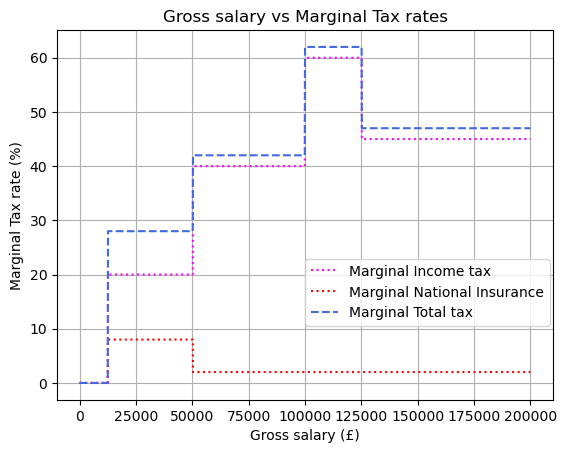

In [1]:
#looking at marginal rates for National Insurance, income tax, and overall tax.

import matplotlib.pyplot as plt

salaries = [0]
marginal_income_tax = [0]
marginal_national_insurance = [0]
marginal_total_rate = [0]

for i in range(2000):
    salaries.append((i+1)*100)
    if salaries[-1] < 12570:
        marginal_income_tax.append(0)
        marginal_national_insurance.append(0)
    elif salaries[-1] < 50270:
        marginal_income_tax.append(20)
        marginal_national_insurance.append(8)
    elif salaries[-1] < 100000:
        marginal_income_tax.append(40)
        marginal_national_insurance.append(2)
    elif salaries[-1] < 125140:
        marginal_income_tax.append(60)
        marginal_national_insurance.append(2)
    else:
        marginal_income_tax.append(45)
        marginal_national_insurance.append(2)
    marginal_total_rate.append(marginal_income_tax[-1] + marginal_national_insurance[-1])
        

plt.plot(salaries,marginal_income_tax,c='fuchsia',ls=':')
plt.plot(salaries,marginal_national_insurance,c='red',ls=':')
plt.plot(salaries,marginal_total_rate,c='royalblue',ls='--')
plt.title('Gross salary vs Marginal Tax rates')
plt.xlabel('Gross salary (£)')
plt.ylabel('Marginal Tax rate (%)')
plt.legend(['Marginal Income tax','Marginal National Insurance','Marginal Total tax'],loc=(0.5,0.2))
plt.grid()
plt.show()

This graph gives us a visualisation of the marginal tax we pay at varying salaries and how this is made up of income tax and National Insurance. Of course, our take-home pay is increasing with salary, but this helps us to see at varying salaries if we earned £1 more, how much of it would be taxed. 

The income tax hit its peak of 60% between £100,000 and £125,140. This is because for every £2 you earn, you lose £1 of your personal allowance, this means that if you earn £2 in this range you pay 40% income tax on that £2 as well as 40% income tax on £1 of your personal allowance, which you've lost. This means you pay £1.20 in income tax for every £2 you earn, making it an effective marginal income tax rate of 60%.

Now that we have an idea of the marginal tax rates, I will make a basic take-home salary calculator below.

In [2]:
#My first take-home salary calculator

def take_home_salary(gross_salary):
    income_tax = 0 #no checks as I am only inputting valid salaries
    national_insurance = 0 
    if gross_salary > 125140:
        income_tax += 0.2 * 37700
        income_tax += 0.4 * 87440 #don't get any personal allowance
        income_tax += 0.45 * (gross_salary - 125140)
        national_insurance += 0.08 * 37700
        national_insurance += 0.02 * (gross_salary - 50270)
    elif 100000 < gross_salary <= 125140:
        income_tax += 0.2 * 37700
        income_tax += 0.4 * 49730 
        income_tax += 0.4 * (3/2)*(gross_salary - 100000) #adjusting for partial removal of personal allowance
        national_insurance += 0.08 * 37700
        national_insurance += 0.02 * (gross_salary - 50270)
    elif 50270 < gross_salary <= 100000:
        income_tax += 0.2 * 37700
        income_tax += 0.4 * (gross_salary - 50270)
        national_insurance += 0.08 * 37700
        national_insurance += 0.02 * (gross_salary - 50270)
    elif 12570 < gross_salary <= 50270:
        income_tax += 0.2 * (gross_salary - 12570)
        national_insurance += 0.08 * (gross_salary - 12570)
    take_home_salary = gross_salary - income_tax - national_insurance
    print(f'Your take-home salary is: £{take_home_salary}')
    print(f'Your income tax is: £{income_tax}')
    print(f'Your national insurance is: £{national_insurance}')
    
take_home_salary(75000)

Your take-home salary is: £54057.4
Your income tax is: £17432.0
Your national insurance is: £3510.6


This is a simple tax calculator. It checks what tax band you are in and then calculates your income tax, National Insurance, and post-tax (take-home) salary from this. I haven't added any checks to make sure that the input value is a non-negative number, as I am just inputting the values myself, so I don't need it. To make sure I hadn't made an error, I verified the values for a few salaries against an online calculator.

As you can see, it works top-down (highest to lowest salaries through if statements), as I thought this would be easiest to account for removal or partial removal of personal allowance. The function works fine, but the code is a little messy, and I thought I could make a more efficient version, so I have done that below.

In [3]:
#improved take-home salary calculator

def take_home_salary_2(gross_salary):
    income_tax = 0
    national_insurance = 0
    national_insurance += 0.08 * max(gross_salary - 12570, 0) #8% of all earnings above £12,570
    national_insurance -= 0.06 * max(gross_salary - 50270, 0) #adjusts for NI being 2% above £50,270
    income_tax += 0.2 * max(gross_salary - 12570, 0) #20% tax
    income_tax += 0.2 * max(gross_salary - 50270, 0) #40% tax
    income_tax += 0.2 * max(gross_salary - 100000, 0) #effective 60% marginal tax rate
    income_tax -= 0.15 * max(gross_salary - 125140, 0) #45% tax, adjusts for difference to 60% effective tax
    take_home_salary = gross_salary - income_tax - national_insurance
    print(f'Your gross salary is: £{format(round(gross_salary),",d")}')
    print(f'Your take-home salary is: £{format(round(take_home_salary),",d")}')
    print(f'Your income tax is: £{format(round(income_tax),",d")}')
    print(f'Your national insurance is: £{format(round(national_insurance),",d")}')

take_home_salary_2(40000)

Your gross salary is: £40,000
Your take-home salary is: £32,320
Your income tax is: £5,486
Your national insurance is: £2,194


In this calculator, the values are formatted and rounded before being shown. The code is also much simpler, as I managed to code the taxes in a way that didn’t need any if statements.

The code is a little unintuitive in the sense that excessive tax is taken and then added back. For example, National Insurance is taxed at 8% for all earnings above £12,570 on the 4th line of the function, and then I reduce it by 6% on earnings above £50,270 in the 5th line to get the desired 2% of earnings above £50,270.

I did this because I wanted to make my code as compact as possible, and National Insurance is highest on earnings from £12,570 to £50,270. I did a similar thing with income tax, taking the difference in tax rates each time.

For the 60% effective marginal tax rate created by the reduction of personal allowance, I treated it as a marginal tax rate of 60% as the two are equivalent in terms of tax paid and take-home salary. As this means that the highest tax band is a lower rate, I had to account for this too in a similar way as to how I did the National Insurance.

### Student Loans:

I wanted to make a calculator which includes student loans. As I said above, it operates somewhat like a graduate tax, and I wanted to create a calculator with student loans as this will be more useful for me personally. I treat it exactly like a tax from here onwards. I am on Plan 2 of student loans, which is:

* 9% of income above £29,385

When making the calculator, I had to see how student loans, income tax, and National Insurance work alongside each other, and I discovered that student loan payments are calculated before tax and taken after. This is a key detail, as it means you pay more to student loans without any tax relief, and it is something I wasn’t aware of before.

To help see the impact student loans have, I wanted to first see the marginal tax rates again, but comparing with and without student loans this time.

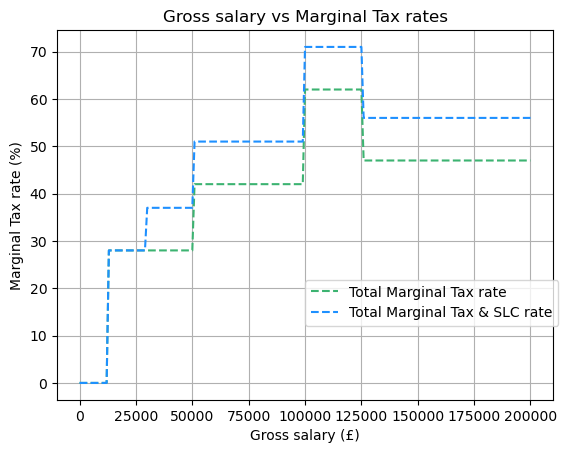

In [4]:
#comparing marginal tax rates with and without student loans. 

import matplotlib.pyplot as plt

salaries_2 = [0]
marginal_total_rate_2 = [0]
marginal_slc_total_rate = [0]

for i in range(200):
    salaries_2.append((i+1)*1000)
    if salaries_2[-1] < 12570:
        marginal_total_rate_2.append(0)
        marginal_slc_total_rate.append(0)
    elif salaries_2[-1] < 29385:
        marginal_total_rate_2.append(28)
        marginal_slc_total_rate.append(28)
    elif salaries_2[-1] < 50270:
        marginal_total_rate_2.append(28)
        marginal_slc_total_rate.append(37)
    elif salaries_2[-1] < 100000:
        marginal_total_rate_2.append(42)
        marginal_slc_total_rate.append(51)
    elif salaries_2[-1] < 125140:
        marginal_total_rate_2.append(62)
        marginal_slc_total_rate.append(71)
    else:
        marginal_total_rate_2.append(47)
        marginal_slc_total_rate.append(56)

        

plt.plot(salaries_2,marginal_total_rate_2,c='mediumseagreen',ls='--')
plt.plot(salaries_2,marginal_slc_total_rate,c='dodgerblue',ls='--')
plt.title('Gross salary vs Marginal Tax rates')
plt.xlabel('Gross salary (£)')
plt.ylabel('Marginal Tax rate (%)')
plt.legend(['Total Marginal Tax rate','Total Marginal Tax & SLC rate'],loc=(0.5,0.2))
plt.grid()
plt.show()

This graph shows the difference between the total marginal tax rate and the total marginal tax rate with student loan payments. Clearly, they are the same below the threshold value, but then student loans makes quite a big difference, in particular you pay a marginal tax rate of 71% on earnings from £100,000 to £125,140.

Now that we have seen the difference in marginal rates and have some idea of how it works, I wanted to make a calculator that includes student loan payments and have done below.

In [5]:
#take-home salary calculator including student loan payments

def take_home_salary_slc(gross_salary):
    income_tax = 0
    national_insurance = 0
    student_loan_repayment = 0
    national_insurance += 0.08 * max(gross_salary - 12570, 0) 
    national_insurance -= 0.06 * max(gross_salary - 50270, 0) 
    income_tax += 0.2 * max(gross_salary - 12570, 0)
    income_tax += 0.2 * max(gross_salary - 50270, 0)
    income_tax += 0.2 * max(gross_salary - 100000, 0)
    income_tax -= 0.15 * max(gross_salary - 125140, 0) 
    student_loan_repayment = 0.09 * max(gross_salary - 29385, 0) #9% of all earnings above £29,385
    take_home_salary = gross_salary - income_tax - national_insurance - student_loan_repayment
    print(f'Your gross salary is: £{format(round(gross_salary),",d")}')
    print(f'Your take-home salary is: £{format(round(take_home_salary),",d")}')
    print(f'Your income tax is: £{format(round(income_tax),",d")}')
    print(f'Your national insurance is: £{format(round(national_insurance),",d")}')
    print(f'Your student loan repayment is: £{format(round(student_loan_repayment),",d")}')
    
take_home_salary_slc(60000)

Your gross salary is: £60,000
Your take-home salary is: £42,602
Your income tax is: £11,432
Your national insurance is: £3,211
Your student loan repayment is: £2,755


It was quite simple to add student loans as it just operates like another tax and doesn’t affect your income tax or National Insurance. You pay the exact same amount of income tax and National Insurance as before, therefore, the student loan payments just eat into your take-home salary.

### Postgraduate Loans:

I wanted to also have a function that includes Student Loans and Postgraduate Loans. The two loans both effectively work as taxes and also work separately from each other and all other types of tax. Postgraduate Loans are:

* 6% of income above £21,000.

The next calculator includes both student loans and postgraduate loans.

In [6]:
#take-home salary calculator including student loan and postgraduate loan payments

def take_home_salary_slc_pg(gross_salary):
    income_tax = 0
    national_insurance = 0
    student_loan_repayment = 0
    national_insurance += 0.08 * max(gross_salary - 12570, 0) 
    national_insurance -= 0.06 * max(gross_salary - 50270, 0) 
    income_tax += 0.2 * max(gross_salary - 12570, 0) 
    income_tax += 0.2 * max(gross_salary - 50270, 0) 
    income_tax += 0.2 * max(gross_salary - 100000, 0) 
    income_tax -= 0.15 * max(gross_salary - 125140, 0)
    student_loan_repayment = 0.09 * max(gross_salary - 29385, 0) 
    post_grad_repayment = 0.06 * max(gross_salary - 21000, 0) #6% of all earnings above £21,000
    take_home_salary = gross_salary - income_tax - national_insurance - student_loan_repayment - post_grad_repayment
    print(f'Your gross salary is: £{format(round(gross_salary),",d")}')
    print(f'Your take-home salary is: £{format(round(take_home_salary),",d")}')
    print(f'Your income tax is: £{format(round(income_tax),",d")}')
    print(f'Your national insurance is: £{format(round(national_insurance),",d")}')
    print(f'Your student loan repayment is: £{format(round(student_loan_repayment),",d")}')
    print(f'Your post graduate student loan repayment is: £{format(round(post_grad_repayment),",d")}')
    
take_home_salary_slc_pg(85000)

Your gross salary is: £85,000
Your take-home salary is: £51,012
Your income tax is: £21,432
Your national insurance is: £3,711
Your student loan repayment is: £5,005
Your post graduate student loan repayment is: £3,840


It was fairly simple again, as they work separately and are separate from income tax and National Insurance. It's similar to just adding another tax as it just eats into the take-home salary and doesn't affect anything else. Having both student loans and postgraduate loans is a big deal and, in particular it means that for earnings between £100,000 and £125,140 you pay an effective marginal tax rate of 77%. 

### Visualisation of Salary Breakdown

The functions so far are useful and give you the breakdown, but it doesn't really give you any visualisation as to what % of your gross salary goes where. I wanted a way to do this, and I thought a pie chart was the best way, so I have done that below. 

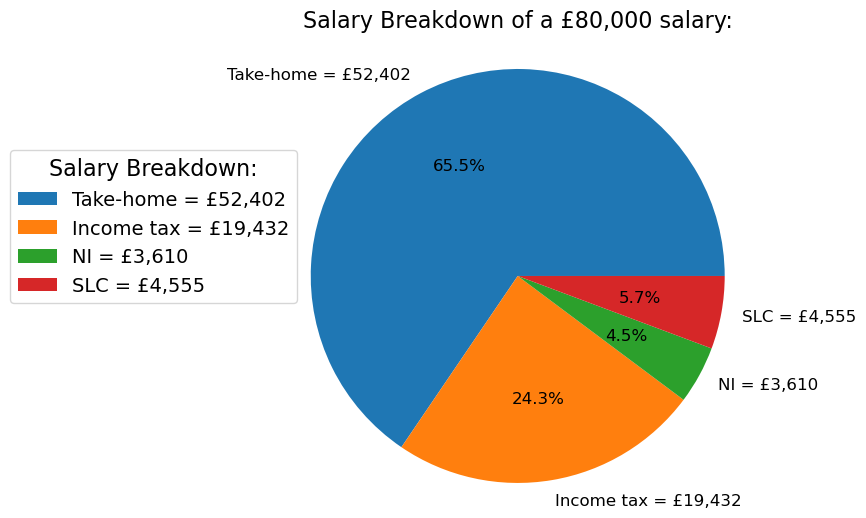

In [7]:
#pie chart of income split with student loan payments

import matplotlib.pyplot as plt
import numpy as np

def take_home_salary_slc_pie_chart(gross_salary):
    income_tax = 0
    national_insurance = 0
    student_loan_repayment = 0
    national_insurance += 0.08 * max(gross_salary - 12570, 0) 
    national_insurance -= 0.06 * max(gross_salary - 50270, 0) 
    income_tax += 0.2 * max(gross_salary - 12570, 0) 
    income_tax += 0.2 * max(gross_salary - 50270, 0) 
    income_tax += 0.2 * max(gross_salary - 100000, 0) 
    income_tax -= 0.15 * max(gross_salary - 125140, 0) 
    student_loan_repayment = 0.09 * max(gross_salary - 29385, 0) 
    take_home_salary = gross_salary - income_tax - national_insurance - student_loan_repayment
    split = np.array([take_home_salary,income_tax,national_insurance,student_loan_repayment])
    my_labels_slc = [f"Take-home = £{format(int(take_home_salary),',d')}", 
                 f"Income tax = £{format(int(income_tax),',d')}", 
                     f"NI = £{format(int(national_insurance),',d')}", 
                 f"SLC = £{format(int(student_loan_repayment),',d')}"]
    plt.pie(split, labels = my_labels_slc,autopct='%1.1f%%',radius = 1.4,textprops={'fontsize': 12}) #pie chart and showing %'s
    plt.title(f"Salary Breakdown of a £{format(int(gross_salary),',d')} salary:",fontsize = '16',y = 1.15) #title
    plt.legend(bbox_to_anchor=(-0.9,0.4),loc="lower left",title = 'Salary Breakdown:',fontsize = '14',title_fontsize = '16') #key for pie chart
    plt.show()
    
take_home_salary_slc_pie_chart(80000)

This visualises the income split really nicely, showing you exactly how much and what percentage of your income goes to each income component. It's a much nicer way of seeing how your salary breaks down than just getting the numbers themselves. I have shortened national insurance and student loans to NI and SLC respectively. The function takes a salary and gives you the income split of it in a pie chart. 

Although student loans affect me now, I still want to know how it affects my take-home salary and what my salary breakdown would look like without them. So below I have made a function which creates two pie charts for a given salary, one with student loans and one without. 

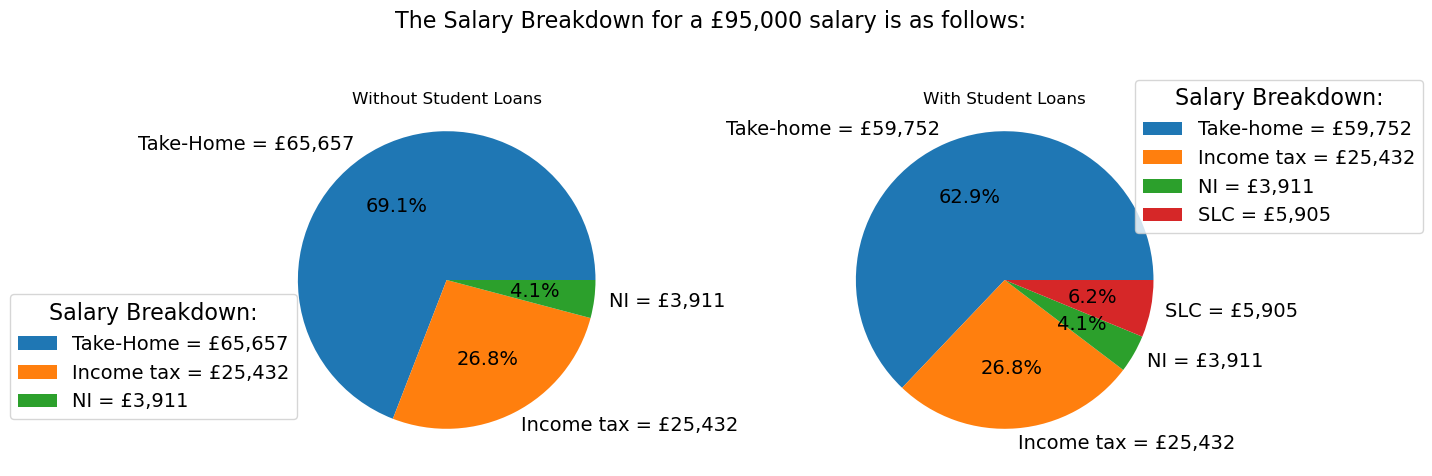

In [8]:
#pie charts of income split, no student loans vs student loans

import matplotlib.pyplot as plt
import numpy as np

def take_home_salary_pie_chart_slc_and_without(gross_salary):
    income_tax = 0
    national_insurance = 0
    national_insurance += 0.08 * max(gross_salary - 12570, 0) 
    national_insurance -= 0.06 * max(gross_salary - 50270, 0)
    income_tax += 0.2 * max(gross_salary - 12570, 0) 
    income_tax += 0.2 * max(gross_salary - 50270, 0) 
    income_tax += 0.2 * max(gross_salary - 100000, 0) 
    income_tax -= 0.15 * max(gross_salary - 125140, 0)
    student_loan_repayment = 0.09 * max(gross_salary - 29385, 0) 
    take_home_salary_without = gross_salary - income_tax - national_insurance
    take_home_salary_slc = gross_salary - income_tax - national_insurance - student_loan_repayment
    split_without = np.array([take_home_salary_without,income_tax,national_insurance]) 
    split_slc = np.array([take_home_salary_slc,income_tax,national_insurance,student_loan_repayment])
    fig, (ax1,ax2) = plt.subplots(1,2,figsize = (12,12)) #Using subplots so I can plot next to each other
    fig.suptitle(f'The Salary Breakdown for a £{format(round(gross_salary),",d")} salary is as follows:', fontsize=16, y = 0.72) #heading
    my_labels_without = [f'Take-Home = £{format(round(take_home_salary_without),",d")}',  
                 f'Income tax = £{format(round(income_tax),",d")}', 
                     f'NI = £{format(round(national_insurance),",d")}'] 
    ax1.pie(split_without,labels = my_labels_without,autopct='%1.1f%%',textprops={'fontsize': 14}) #labels and showing %'s
    ax1.legend(bbox_to_anchor=(-0.7,0.1),loc="lower left",title = 'Salary Breakdown:',fontsize = '14',title_fontsize = '16') #adding key
    ax1.set_title('Without Student Loans',y=0.95) #titling subplot 
    my_labels_slc = [f'Take-home = £{format(round(take_home_salary_slc),",d")}', 
                 f'Income tax = £{format(round(income_tax),",d")}', 
                     f'NI = £{format(round(national_insurance),",d")}', 
                 f'SLC = £{format(round(student_loan_repayment),",d")}']
    ax2.pie(split_slc,labels = my_labels_slc,autopct='%1.1f%%',textprops={'fontsize': 14})
    ax2.legend(bbox_to_anchor=(1.65,0.6),loc="lower right",title = 'Salary Breakdown:',fontsize = '14',title_fontsize = '16')
    ax2.set_title('With Student Loans',y=0.95)
    plt.subplots_adjust(wspace=0.5) #adjusting space in between
    plt.show()

take_home_salary_pie_chart_slc_and_without(95000)

I feel this is a very nice way to compare the split of your salary with and without student loans. To make the comparison easier, I made the pie charts adjacent. As I said before, you pay the same income tax and national insurance regardless of whether you have student loans or not. This means that the student loan payments just eat into your take-home salary, which we can clearly see above. This visualisation is especially useful for people who have student loans and want to know how much their take-home pay will increase when they pay them off. 

This comparison is nice, but there is also the possibility of postgraduate loans. I wanted to make a visualisation of that comparison too, comparing the breakdown of salary with and without student and postgraduate loans. 

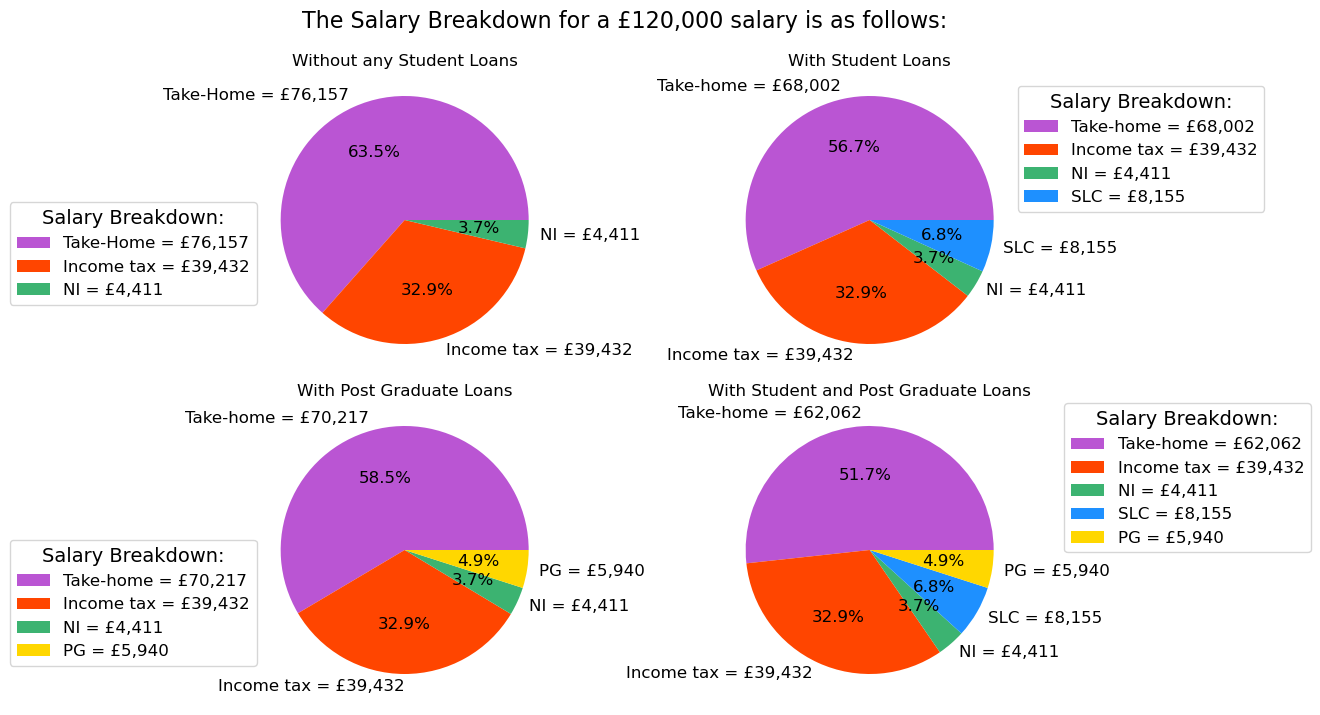

In [9]:
#pie charts comparing salary breakdown with and without student and postgraduate loans

import matplotlib.pyplot as plt
import numpy as np

def take_home_salary_slc_pg_pie_charts(gross_salary):
    income_tax = 0
    national_insurance = 0
    student_loan_repayment = 0
    national_insurance += 0.08 * max(gross_salary - 12570, 0) 
    national_insurance -= 0.06 * max(gross_salary - 50270, 0) 
    income_tax += 0.2 * max(gross_salary - 12570, 0) 
    income_tax += 0.2 * max(gross_salary - 50270, 0) 
    income_tax += 0.2 * max(gross_salary - 100000, 0) 
    income_tax -= 0.15 * max(gross_salary - 125140, 0)
    student_loan_repayment = 0.09 * max(gross_salary - 29385, 0) 
    post_grad_repayment = 0.06 * max(gross_salary - 21000, 0)
    take_home_salary_without = gross_salary - income_tax - national_insurance
    take_home_salary_slc = gross_salary - income_tax - national_insurance - student_loan_repayment
    take_home_salary_pg = gross_salary - income_tax - national_insurance - post_grad_repayment
    take_home_salary_slc_pg = gross_salary - income_tax - national_insurance - student_loan_repayment - post_grad_repayment
    
    split_without = np.array([take_home_salary_without,income_tax,national_insurance]) 
    split_slc = np.array([take_home_salary_slc,income_tax,national_insurance,student_loan_repayment])
    split_pg = np.array([take_home_salary_pg,income_tax,national_insurance,post_grad_repayment])
    split_slc_pg = np.array([take_home_salary_slc_pg,income_tax,national_insurance,student_loan_repayment,post_grad_repayment])
    
    fig, axes = plt.subplots(2,2,figsize = (10,10)) 
    fig.suptitle(f'The Salary Breakdown for a £{format(round(gross_salary),",d")} salary is as follows:', fontsize=16, y = 0.87) 
    my_labels_without = [f'Take-Home = £{format(round(take_home_salary_without),",d")}',  
                 f'Income tax = £{format(round(income_tax),",d")}', 
                     f'NI = £{format(round(national_insurance),",d")}'] 
    my_colours_without = ['mediumorchid','orangered','mediumseagreen']
    axes[0,0].pie(split_without,labels = my_labels_without,colors= my_colours_without,autopct='%1.1f%%',textprops={'fontsize': 12}) 
    axes[0,0].legend(bbox_to_anchor=(-0.8,0.2),loc="lower left",title = 'Salary Breakdown:',fontsize = '12',title_fontsize = '14') 
    axes[0,0].set_title('Without any Student Loans',y=0.97) 
    
    my_labels_slc = [f'Take-home = £{format(round(take_home_salary_slc),",d")}', 
                 f'Income tax = £{format(round(income_tax),",d")}', 
                     f'NI = £{format(round(national_insurance),",d")}', 
                 f'SLC = £{format(round(student_loan_repayment),",d")}']
    my_colours_slc = ['mediumorchid','orangered','mediumseagreen','dodgerblue']
    axes[0,1].pie(split_slc,labels = my_labels_slc,colors= my_colours_slc,autopct='%1.1f%%',textprops={'fontsize': 12})
    axes[0,1].legend(bbox_to_anchor=(1.8,0.5),loc="lower right",title = 'Salary Breakdown:',fontsize = '12',title_fontsize = '14')
    axes[0,1].set_title('With Student Loans',y=0.97)
    
    my_labels_pg = [f'Take-home = £{format(round(take_home_salary_pg),",d")}', 
                 f'Income tax = £{format(round(income_tax),",d")}', 
                     f'NI = £{format(round(national_insurance),",d")}', 
                 f'PG = £{format(round(post_grad_repayment),",d")}']
    my_colours_pg = ['mediumorchid','orangered','mediumseagreen','gold']
    axes[1,0].pie(split_pg,labels = my_labels_pg,colors= my_colours_pg,autopct='%1.1f%%',textprops={'fontsize': 12})
    axes[1,0].legend(bbox_to_anchor=(-0.8,0.1),loc="lower left",title = 'Salary Breakdown:',fontsize = '12',title_fontsize = '14')
    axes[1,0].set_title('With Post Graduate Loans',y=0.97)
    
    my_labels_slc_pg = [f'Take-home = £{format(round(take_home_salary_slc_pg),",d")}', 
                 f'Income tax = £{format(round(income_tax),",d")}', 
                     f'NI = £{format(round(national_insurance),",d")}', 
                 f'SLC = £{format(round(student_loan_repayment),",d")}',
                    f'PG = £{format(round(post_grad_repayment),",d")}']
    my_colours_slc_pg = ['mediumorchid','orangered','mediumseagreen','dodgerblue','gold']
    axes[1,1].pie(split_slc_pg,labels = my_labels_slc_pg,colors = my_colours_slc_pg,autopct='%1.1f%%',textprops={'fontsize': 12})
    axes[1,1].legend(bbox_to_anchor=(1.95,1),loc='upper right',title = 'Salary Breakdown:',fontsize = '12',title_fontsize = '14')
    axes[1,1].set_title('With Student and Post Graduate Loans',y=0.97)
    plt.subplots_adjust(wspace=0.5)
    plt.subplots_adjust(hspace=-0.25)
    plt.show()
    
take_home_salary_slc_pg_pie_charts(120000)

The above function, for a given salary, visualises the income breakdown for four options, these are:

- No Student loans
- Plan 2 Student Loans
- Postgraduate Student Loans
- Both Plan 2 and Postgraduate Student Loans

The differences in take-home salary are significant for the above salary and only grow as salary increases. I changed the colours of the pie chart here so that each different section of salary would be consistent, i.e. Postgraduate Loans are in Yellow for both the bottom pie charts. Whilst only one of the four pie charts above can apply to any one individual, it is a useful comparison for those with student (plan 2) and/or postgraduate loans or those considering taking out postgraduate loans. 

I next wanted to see how the effective tax rate (total tax paid over gross salary) changes with salary, and I have shown this as well as the marginal tax rates and take-home salary in the graphs below.

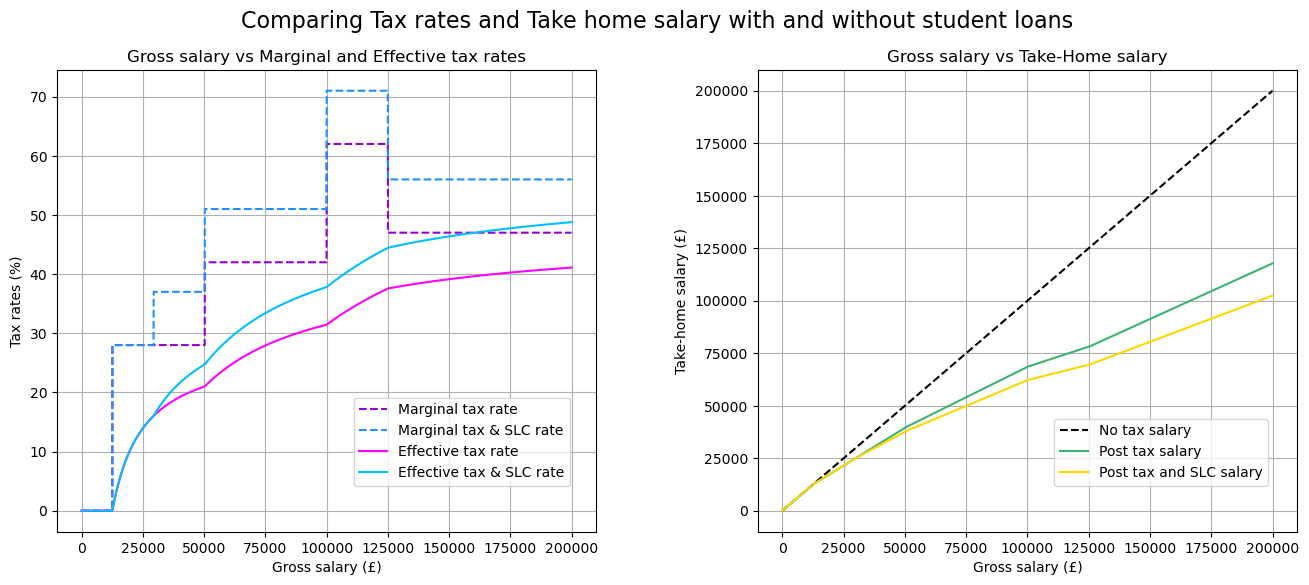

In [10]:
#comparing marginal and effective tax rates as well as take-home income with and without slc.

import matplotlib.pyplot as plt

def take_home_salary_graph(gross_salary):
    income_tax = 0
    national_insurance = 0
    national_insurance += 0.08 * max(gross_salary - 12570, 0) 
    national_insurance -= 0.06 * max(gross_salary - 50270, 0) 
    income_tax += 0.2 * max(gross_salary - 12570, 0) 
    income_tax += 0.2 * max(gross_salary - 50270, 0)
    income_tax += 0.2 * max(gross_salary - 100000, 0)
    income_tax -= 0.15 * max(gross_salary - 125140, 0)
    take_home_salary = gross_salary - income_tax - national_insurance
    return take_home_salary

def take_home_salary_slc_graph(gross_salary):
    income_tax = 0
    national_insurance = 0
    student_loan_repayment = 0
    national_insurance += 0.08 * max(gross_salary - 12570, 0)
    national_insurance -= 0.06 * max(gross_salary - 50270, 0) 
    income_tax += 0.2 * max(gross_salary - 12570, 0)
    income_tax += 0.2 * max(gross_salary - 50270, 0)
    income_tax += 0.2 * max(gross_salary - 100000, 0)
    income_tax -= 0.15 * max(gross_salary - 125140, 0) 
    student_loan_repayment = 0.09 * max(gross_salary - 29385, 0) 
    take_home_salary = gross_salary - income_tax - national_insurance - student_loan_repayment
    return take_home_salary

salaries_3 = [0]
effective_tax_rate = [0]
effective_tax_slc_rate = [0]
marginal_tax_rate = [0]
marginal_tax_slc_rate = [0]
take_home_salaries = [1]
take_home_salaries_slc = [1]

for i in range(20000):
    salaries_3.append((i+1)*10)
    if salaries_3[-1] < 12570:
        marginal_tax_rate.append(0)
        marginal_tax_slc_rate.append(0)
    elif salaries_3[-1] < 29385:
        marginal_tax_rate.append(28)
        marginal_tax_slc_rate.append(28)
    elif salaries_3[-1] < 50270:
        marginal_tax_rate.append(28)
        marginal_tax_slc_rate.append(37)
    elif salaries_3[-1] < 100000:
        marginal_tax_rate.append(42)
        marginal_tax_slc_rate.append(51)
    elif salaries_3[-1] < 125000:
        marginal_tax_rate.append(62)
        marginal_tax_slc_rate.append(71)
    else:
        marginal_tax_rate.append(47)
        marginal_tax_slc_rate.append(56)
    effective_tax_rate.append(100*(1-(take_home_salary_graph(salaries_3[-1])/salaries_3[-1])))
    effective_tax_slc_rate.append(100*(1-(take_home_salary_slc_graph(salaries_3[-1])/salaries_3[-1])))
    take_home_salaries.append(take_home_salary_graph(salaries_3[-1]))
    take_home_salaries_slc.append(take_home_salary_slc_graph(salaries_3[-1]))

fig, (ax1,ax2) = plt.subplots(1,2,figsize = (16,6))
fig.suptitle('Comparing Tax rates and Take home salary with and without student loans',fontsize='16')
ax1.plot(salaries_3,marginal_tax_rate,c='darkviolet',ls='--')
ax1.plot(salaries_3,marginal_tax_slc_rate,c='dodgerblue',ls='--')
ax1.plot(salaries_3,effective_tax_rate,c='fuchsia')
ax1.plot(salaries_3,effective_tax_slc_rate,c = 'deepskyblue')
ax1.set_title('Gross salary vs Marginal and Effective tax rates')
ax1.set_xlabel('Gross salary (£)')
ax1.set_ylabel('Tax rates (%)')
ax1.legend(['Marginal tax rate','Marginal tax & SLC rate','Effective tax rate', 'Effective tax & SLC rate'],loc = (0.55,0.1))
ax1.grid()

ax2.plot(salaries_3,salaries_3,c= 'black',ls='--')
ax2.plot(salaries_3,take_home_salaries,c='mediumseagreen')
ax2.plot(salaries_3,take_home_salaries_slc,c = 'gold')
ax2.set_title('Gross salary vs Take-Home salary')
ax2.set_xlabel('Gross salary (£)')
ax2.set_ylabel('Take-home salary (£)')
ax2.legend(['No tax salary','Post tax salary','Post tax and SLC salary'],loc = (0.55,0.1))
ax2.grid()
plt.subplots_adjust(wspace=0.3)
plt.show()

The graphs above compare the difference in effective and marginal tax rates with and without student loans for salaries up to £200,000. The effective tax rate is simply calculated by: 
$
\text{Effective tax rate} = \frac{\text{Total tax and SLC paid}}{\text{Gross salary}}
$.

The left graph is a nice way to compare both marginal and effective tax rates, and the right graph is a nice comparison of your take-home salary. This gives you a good idea of how much tax (& SLC) you are paying and how this changes with salary. The effective tax rate is less than the marginal rate, as the marginal tax rate is the rate of tax for the band you are in, and in general higher tax bands have higher taxes (apart from the 60% effective marginal rate).

### Comparing Take-Home Salary UK vs US

I became interested in American taxes and how they work. I might want to live in America someday and would like to know roughly how the taxes work. I won't state the exact details, but there are a few types of taxes I list below:
- Federal tax (income tax)
- FICA - Social Security and Medicare (Similar to National Insurance)
- State Tax
- Local Area Tax (or City Tax)

Note that some states have no State or Local Area Tax, such as Texas or Florida. To get an idea of the tax rates in America, I wanted to compare the take-home salaries of the UK, New York, and states with just Federal and FICA taxes. I have done so below. 

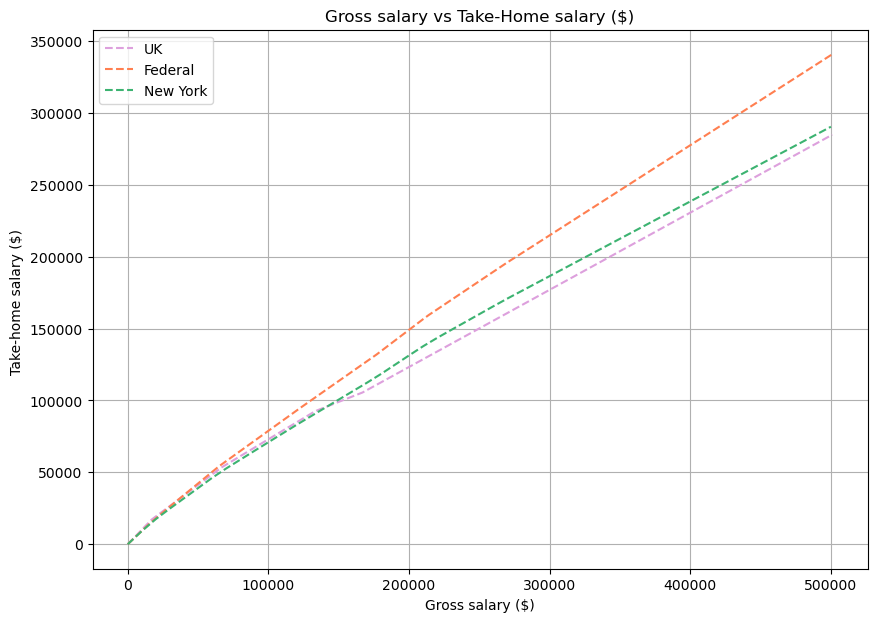

In [11]:
#comparing UK taxes with some US states

import matplotlib.pyplot as plt

def take_home_salary_federal_graph(gross_salary):
    federal_tax = 0
    social_security = 0
    medicare = 0
    taxable_salary = gross_salary - 15750
    medicare += 0.0145 * gross_salary
    medicare += 0.009 * max((gross_salary - 200000),0) #if gross salary < $200,000 then doesn't add anything
    social_security += 0.062 * min(176100,gross_salary) #can apply taxes using similar method and the difference between tax bands I think
    federal_tax += 0.1 * max(taxable_salary,0) #10% tax
    federal_tax += 0.02 * max(taxable_salary - 11925, 0) #12% tax
    federal_tax += 0.1 * max(taxable_salary - 48475, 0) #22% tax
    federal_tax += 0.02 * max(taxable_salary - 103350, 0) #24% tax
    federal_tax += 0.08 * max(taxable_salary - 197300, 0) #32% tax
    federal_tax += 0.03 * max(taxable_salary - 250525, 0) #35% tax
    federal_tax += 0.02 * max(taxable_salary - 626350, 0) #37% tax
    take_home_salary = gross_salary - federal_tax - social_security - medicare
    return take_home_salary

def take_home_salary_graph_2(gross_salary):
    income_tax = 0
    national_insurance = 0
    national_insurance += 0.08 * max(gross_salary - 12570, 0) 
    national_insurance -= 0.06 * max(gross_salary - 50270, 0) 
    income_tax += 0.2 * max(gross_salary - 12570, 0) 
    income_tax += 0.2 * max(gross_salary - 50270, 0)
    income_tax += 0.2 * max(gross_salary - 100000, 0)
    income_tax -= 0.15 * max(gross_salary - 125140, 0)
    take_home_salary = gross_salary - income_tax - national_insurance
    return take_home_salary

take_home_new_york = [0,9165,17500,24838,31947,39052,46156,52680,58778,64875,70923,76971,83001,88849,94697,100545,106393,112241,118330,124798,
                      131266,137644,143466,148997,154490,159983,165476,170857,176050,181243,186436,191629,196822,202015,207208,212401,217594,
                      222787,227980,233173,238366,243559,248752,253945,259138,264331,269524,274717,279910,285103,290296]


salaries_4 = [0]
salaries_5 = [10000*i for i in range(51)]
take_home_uk = [0]
take_home_federal = [0]
for i in range(501):
    salaries_4.append(1000*(i+1))
    take_home_uk.append(1.35*take_home_salary_graph_2(0.75*salaries_4[-1]))
    take_home_federal.append(take_home_salary_federal_graph(salaries_4[-1]))
        
plt.figure(figsize=(10,7))                             
plt.plot(salaries_4,take_home_uk,c='plum',ls='--')
plt.plot(salaries_4,take_home_federal,c = 'coral',ls='--')
plt.plot(salaries_5,take_home_new_york,c = 'mediumseagreen',ls='--')
plt.title("Gross salary vs Take-Home salary ($)")
plt.xlabel("Gross salary ($)")
plt.ylabel("Take-home salary ($) ")
plt.legend(['UK', 'Federal','New York'])
plt.grid()
plt.show()

This graph compares how the take-home salary changes with incomes up to \\$500,000. You can see that all three different tax systems give you a similar take-home income for lower incomes, and the gap grows with income. As the top tax bracket in the UK is lower than in New York, they cross again above $500,000. I coded a tax calculator which works for states with no income tax. For the New York values, I didn’t make a calculator; instead, I used one online and input the take-home values I got from it. This is because the New York tax system is extremely complex, and I couldn’t find out exactly how it worked. I also had to convert the UK tax calculator to dollars. This gives a nice visualisation of take-home income vs gross salary.

### Checking my Tax Calculator

Finally, I wanted to check that my calculations were accurate. To do this, I want to compare the take-home pay I calculated vs. the take-home pay calculated via the HMRC website for varying salaries. To make sure my calculator works well, I have also compared the values at tax and student loan repayment thresholds to make sure it is behaving properly.

In [12]:
#making the list of salaries to check my calculator for against HMRC's

varied_salaries = [30000*(i+1) for i in range(5)]
tax_bands = [12570,50270,100000,125140]
slc_threshold = 29385
post_grad_threshold = 21000
testing_values = []
testing_values_slc = []
testing_values_pg = []
testing_values_slc_pg = []
for i in varied_salaries:
    testing_values.append(i)
    testing_values_slc.append(i)
    testing_values_pg.append(i)
    testing_values_slc_pg.append(i)
for i in tax_bands:
    for j in range(-1,2):
        testing_values.append(i+j)
        testing_values_slc.append(i+j)
        testing_values_pg.append(i+j)
        testing_values_slc_pg.append(i+j)
for j in range(-1,2):
    testing_values_slc.append(slc_threshold+j)
    testing_values_slc_pg.append(slc_threshold+j)
for j in range(-1,2):
    testing_values_pg.append(post_grad_threshold+j)
    testing_values_slc_pg.append(post_grad_threshold+j)
    
testing_values.sort()
testing_values_slc.sort()
testing_values_pg.sort()
testing_values_slc_pg.sort()

print('The salaries to test against without any student loans are: ', testing_values)
print('The salaries to test against with just student loans are: ', testing_values_slc)
print('The salaries to test against with just post graduate loans are: ', testing_values_pg)
print('The salaries to test against with student and post graduate loans are: ', testing_values_slc_pg)

The salaries to test against without any student loans are:  [12569, 12570, 12571, 30000, 50269, 50270, 50271, 60000, 90000, 99999, 100000, 100001, 120000, 125139, 125140, 125141, 150000]
The salaries to test against with just student loans are:  [12569, 12570, 12571, 29384, 29385, 29386, 30000, 50269, 50270, 50271, 60000, 90000, 99999, 100000, 100001, 120000, 125139, 125140, 125141, 150000]
The salaries to test against with just post graduate loans are:  [12569, 12570, 12571, 20999, 21000, 21001, 30000, 50269, 50270, 50271, 60000, 90000, 99999, 100000, 100001, 120000, 125139, 125140, 125141, 150000]
The salaries to test against with student and post graduate loans are:  [12569, 12570, 12571, 20999, 21000, 21001, 29384, 29385, 29386, 30000, 50269, 50270, 50271, 60000, 90000, 99999, 100000, 100001, 120000, 125139, 125140, 125141, 150000]


I chose a variety of standard salaries to test against, and also the tax and student loan thresholds (if applicable). I have done this for all student loan possibilities (with and without student and postgraduate loans) to make sure they are all working correctly. 

In [13]:
#checking my calculator against HMRC's

def take_home_salary_all_test(gross_salary):
    income_tax = 0
    national_insurance = 0
    student_loan_repayment = 0
    national_insurance += 0.08 * max(gross_salary - 12570, 0) 
    national_insurance -= 0.06 * max(gross_salary - 50270, 0) 
    income_tax += 0.2 * max(gross_salary - 12570, 0) 
    income_tax += 0.2 * max(gross_salary - 50270, 0) 
    income_tax += 0.2 * max(gross_salary - 100000, 0) 
    income_tax -= 0.15 * max(gross_salary - 125140, 0)
    student_loan_repayment = 0.09 * max(gross_salary - 29385, 0) 
    post_grad_repayment = 0.06 * max(gross_salary - 21000, 0) #6% of all earnings above £21,000
    take_home_salary_without = gross_salary - income_tax - national_insurance
    take_home_salary_slc = gross_salary - income_tax - national_insurance - student_loan_repayment
    take_home_salary_pg = gross_salary - income_tax - national_insurance - post_grad_repayment
    take_home_salary_slc_pg = gross_salary - income_tax - national_insurance - student_loan_repayment - post_grad_repayment
    take_home_salaries = [take_home_salary_without,take_home_salary_slc,take_home_salary_pg,take_home_salary_slc_pg]
    return take_home_salaries

take_home_salary_hmrc = [12569,12570,12570.92,25121.40,39715.08,39715.80,39716.58,45361,62761,68560.42,68561,68561.38,76161,78113.82,78114.20,78114.58,91286.40]

take_home_salary_hmrc_slc = [12569,12570,12570.92,24677.88,24678.60,24679.32,25066.40,37836.08,37836.80,37837.58,42606,57306,62205.42,62206,62206.38,68006,69496.82,
                             69497.20,69496.58,80431.40]

take_home_salary_hmrc_pg = [12569,12570,12570.92,18640.68,18641.40,18642.12,24581.40,37959.08,37959.80,37960.58,43021,58621,63821.42,63821,63821.38,70221,71865.82,
                            71866.20,71866.58,83546.40]

take_home_salary_hmrc_slc_pg = [12569,12570,12570.92,18640.68,18641.40,18642.12,24174.88,24175.60,24176.32,24526.40,36080.08,36080.80,36081.58,40266,53166,57466.42,
                                57466,57466.38,62066,63248.82,63249.20,63248.58,72691.40]

differences = []
for i in range(len(testing_values)):
    differences.append(abs(take_home_salary_hmrc[i] - take_home_salary_all_test(testing_values[i])[0]))
    
for i in range(len(testing_values_slc)):
    differences.append(abs(take_home_salary_hmrc_slc[i] - take_home_salary_all_test(testing_values_slc[i])[1]))
    
for i in range(len(testing_values_pg)):
    differences.append(abs(take_home_salary_hmrc_pg[i] - take_home_salary_all_test(testing_values_pg[i])[2]))
    
for i in range(len(testing_values_slc_pg)):
    differences.append(abs(take_home_salary_hmrc_slc_pg[i] - take_home_salary_all_test(testing_values_slc_pg[i])[3])) 
    
differences.sort()
print(f'The biggest difference in take home pay in my tax calculator vs the HMRC calculator is: £{round(differences[-1],2)}')
print(f'The smallest difference in take home pay in my tax calculator vs the HMRC calculator is: £{round(differences[0],2)}')
print(f'The median difference in take home pay in my tax calculator vs the HMRC calculator is: £{round((differences[39]+differences[40])/2,2)}')

The biggest difference in take home pay in my tax calculator vs the HMRC calculator is: £4.95
The smallest difference in take home pay in my tax calculator vs the HMRC calculator is: £0.0
The median difference in take home pay in my tax calculator vs the HMRC calculator is: £2.48


As I am comparing the take-home salary, I just slightly edited the pie chart function to return the various take-home salaries. I used the HMRC calculator for each of the salaries and then compared the absolute difference between my calculation for take-home pay and the HMRC calculation. Overall, I compared 80 different values from a wide range of salaries across all student loan cases.

As you can see the largest difference between my tax calculator and HMRC’s is just £5. The smallest difference is £0, and the median is £2.48, so overall this shows my calculator is very accurate and reliable.

One reason for the differences is that HMRC takes the floor of the payments for student and postgraduate loans. I also did my calculator for yearly salary and simply did it as if you were paid once a year, which isn’t the case for the vast majority of people. This would change the values very slightly and is likely another reason for the error. I compared against the values for getting paid annually, but I believe some calculations on the HMRC website could be done monthly and then converted, as the majority of people are paid monthly. Overall, a £5 error between take-home salaries is negligible and shows that my calculator is very accurate and is a useful tool for seeing the breakdown of your salary.

## Summary

Overall, I’m happy with my calculator and the functions. I think this is a useful tool to have for future reference and would be easily adapted for future changes in tax bands or student loan repayment thresholds. I’ve learnt a lot about how the tax system works and am glad I did this because of that alone. For example, I wasn’t aware that student and postgraduate loan repayments both work separately and are also calculated before tax and taken after. This means that you pay more student loans and don’t get any tax relief, which is a key detail.

There are definitely things I could improve upon. For example, having a function that inputs your type of student loan would be better generally, as I just focused on the one student loan type, which affects me as well as postgraduate loans. I could also have an input for pension contributions, as this can reduce your taxable income. Another improvement I could make is adapting the function for monthly salary; this could mean just taking monthly salary and giving a monthly breakdown back, or adjusting the yearly salary for getting paid monthly, as most people are paid monthly in the UK.

It was useful to see the breakdown of salaries and see how the marginal tax rates change with salary and how they are affected by student loan payments. Knowing this is beneficial and could also help you make financial decisions. The incentive to work much harder to get paid more is much less for someone with student loans earning £100,000, as they will only get £0.29 of their next £1, in a similar sense, if you are a high earner, it often makes sense to pay into your pension to reduce taxable income. One thing I’m very glad I did was that I formatted the salaries and rounded the values; this made it so much easier to read the numbers and helps with presentation a lot. That being said, there are many other rules and stuff not considered here, like how the allowance you can pay into your pension before tax is reduced for high earners. Overall, this is a useful tool to have and has given me a better and more complete understanding of the UK tax and Student Loans system.